In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

In [3]:
#%pylab nbagg
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [4]:
%%capture

import numpy as np
import time as tm
import matplotlib.pyplot as plt        
import matplotlib.gridspec as gridspec 

#import sys
#import os
#import scipy.io as io
from math import pi
###############################################################################

#The Virtual Brain
#from tvb.simulator.lab import *       #doesn't work on cluster
import tvb
#import tvb.simulator.simulator as simulator
#import tvb.simulator.models as models
#import tvb.simulator.coupling as coupling
#import tvb.simulator.integrators as integrators
#import tvb.simulator.noise as noise
#import tvb.simulator.monitors as monitors
#import tvb.datatypes.connectivity as connectivity
from tvb.simulator.lab import *

#from thetanmm.model import Theta2D
#import thetanmm.model as models 

#Freq Decomposition
from scipy import signal
from scipy.signal import argrelextrema
from scipy.signal import butter, lfilter, freqz
#Clustering
from sklearn.cluster import KMeans
#PCA
from sklearn.decomposition import PCA

from scipy import stats
from scipy.sparse import rand
import networkx as nx

In [5]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 16)
print(viridis)

In [6]:
sys.path.insert(0, '/Users/giovanni/Documents/GitHub/fufo/')
from src import analysis, simulation, model_HH_ABH 

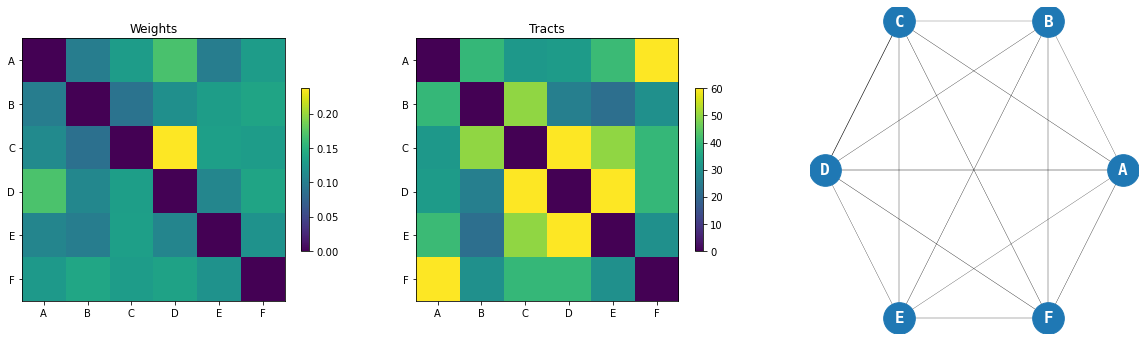

In [7]:
####################################################################
# IMPORT STRUCTURAL CONNECTIVITY
####################################################################
SC6_con = connectivity.Connectivity.from_file("/Users/giovanni/Desktop/Neuro/tvb_codes/connectivity/6x6full.zip")

nregions = len(SC6_con.weights)   
condspeed=np.infty #np.float(1.)
SC6_con.speed = np.array([condspeed])
np.fill_diagonal(SC6_con.weights, 0.)
#np.fill_diagonal(SC6_con.tract_lengths, 0.)

#normalization
SC6_con.configure()

SC6 = SC6_con.weights
SC6_tracts = SC6_con.tract_lengths
SC6_labels = ['A','B','C','D','E','F']

plt.figure(figsize=(20,6))
plt.subplot(131)
plt.imshow(SC6);plt.xticks(np.arange(6),SC6_labels);plt.yticks(np.arange(6),SC6_labels);plt.title('Weights');plt.colorbar(shrink=0.5)
plt.subplot(132)
plt.imshow(SC6_tracts);plt.xticks(np.arange(6),SC6_labels);plt.yticks(np.arange(6),SC6_labels);plt.title('Tracts');plt.colorbar(shrink=0.5)
plt.subplot(133)
G=nx.from_numpy_matrix(SC6_tracts)
def listToDict(lst):
    op = { i : lst[i] for i in range(0, len(lst) ) }
    return op
lab=listToDict(SC6_labels)
weights = 2.5*SC6[np.triu_indices(len(SC6),1)]
nx.draw_circular(G,labels=lab, width=weights, node_size=1000,font_color='w',font_size=16,font_weight='bold',font_family='monospace')

# MONTBRIO, PAZO, ROXIN 2015

In [8]:
# 'E', 'K_bath', 'J', 'eta', 'Delta', 'G','c_minus','R_minus','c_plus','R_plus','Vstar'
E = 0
K_bath = 15.5
J=0.08
eta=0
Delta=1
R_minus=0.02
R_plus=-0.1
c_minus=-44.24
c_plus=-20.4
Vstar = -31
G = 0.


THH = model_HH_ABH.InfiniteHH(
            E = np.r_[E],
            K_bath = np.r_[K_bath],
            J = np.r_[J],
            eta = np.r_[eta],
            Delta = np.r_[Delta],
            c_minus = np.r_[c_minus],
            R_minus = np.r_[R_minus],
            c_plus = np.r_[c_plus],
            R_plus = np.r_[R_plus],
            Vstar = np.r_[Vstar],
            G = np.r_[G])

In [12]:
def configure_single_node_sim(
    model,
    initial_conditions=None,
    sim_len=6000,
    deterministic=True,
    noise_sigma=0.0,
    dt=0.01,
):
    """ Configures a single node simulation.

    Parameters
    sim_len        length [ms] of simulation
    deterministic  no noise if set to True (default True)
    dt             integration step (default 0.01)

    Returns:
    sim            configured simulator instance
    """

    conn = connectivity.Connectivity()
    conn.weights=np.zeros((2,2))
    conn.tract_lengths=np.zeros((2,2))
    conn.centres=np.zeros((2,3))
    conn.number_of_regions=2
    conn.region_labels = np.array(["A","ignore"])

    con_coupling = coupling.Scaling()

    if deterministic:
        integrator = integrators.RungeKutta4thOrderDeterministic(dt=dt)
    else:
        nsigma = noise_sigma
        hiss = noise.Additive(nsig=np.array([nsigma,nsigma*2]))
        integrator = integrators.HeunStochastic(dt=dt, noise=hiss)

    mntrs = [monitors.Raw()]

    if initial_conditions is not None:
        initial_conditions = np.stack(
                [initial_conditions,initial_conditions],
                axis=1
        )[np.newaxis,:,:, np.newaxis]

    sim = simulator.Simulator(model=model,
                              connectivity=conn,
                              coupling=con_coupling,
                              integrator=integrator,
                              monitors=mntrs,
                              simulation_length=sim_len)
    if initial_conditions is not None:
        sim.initial_conditions = initial_conditions

    sim.configure()

    return sim

In [13]:
sim = configure_single_node_sim(
    THH, 
    sim_len=20000,
    dt=0.1,
    initial_conditions=np.r_[0.1,-15.0, 0.45, -5, -16.0],
    deterministic=True
)

In [14]:
eqn_t = equations.Sinusoid()
eqn_t.parameters['amp'] = 0.
eqn_t.parameters['frequency'] = 3.14/12
stimulus = patterns.StimuliRegion(
    temporal=eqn_t,
    connectivity=sim.connectivity,
    weight=np.ones(sim.connectivity.number_of_regions)
)

sim.stimulus = stimulus
sim.configure();

In [15]:
(raw_time, raw_data), = sim.run()

In [19]:
x = raw_data[-60000:,0,0,0]
V = raw_data[-60000:,1,0,0]
n = raw_data[-60000:,2,0,0]
DKi = raw_data[-60000:,3,0,0]
Kg = raw_data[-60000:,4,0,0]

In [17]:
raw_data[-60000:,0,:,0].shape

(60000, 2)

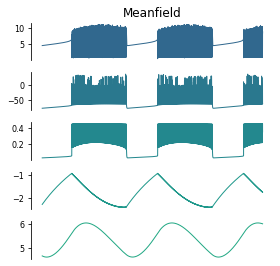

In [18]:
fig = plt.figure(figsize=(4,3.8))
ax1 = fig.add_subplot(511)
ax1.set_title('Meanfield')
ax1.plot((1000*R_minus/np.pi)*x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
#plt.savefig('Figures/J2Regime.pdf')
plt.show()

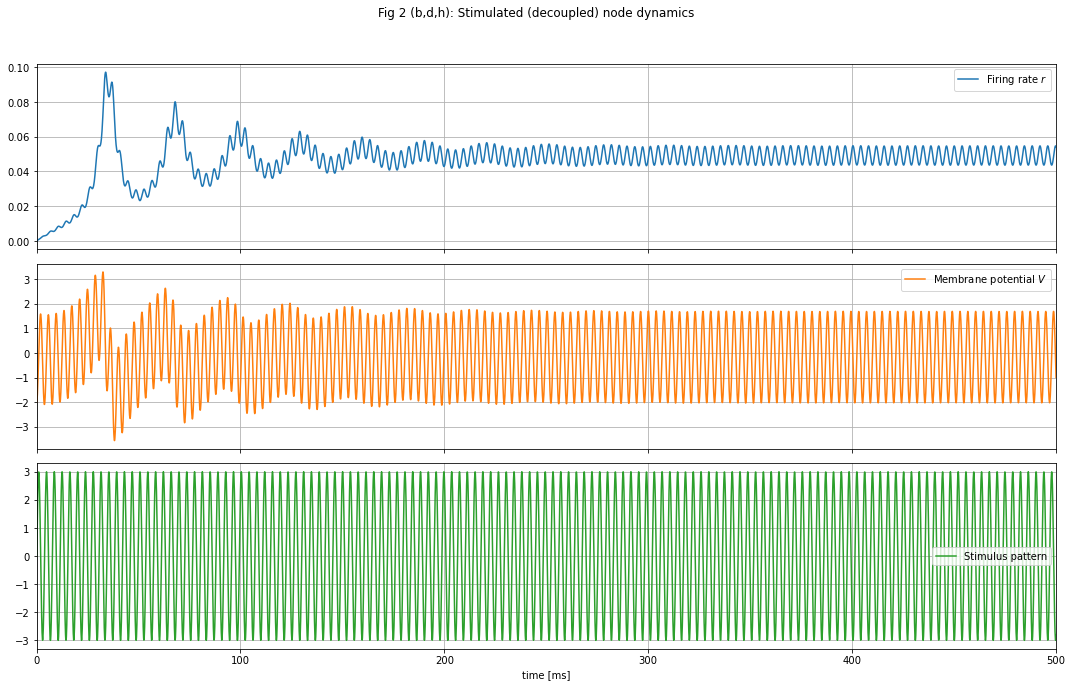

In [56]:
fig, axs = plt.subplots(nrows=3, sharex=True, figsize=(15,10))
pattern = sim.stimulus.temporal_pattern[0]

prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

for i, (var, label) in enumerate([(r,'Firing rate $r$'), (V,'Membrane potential $V$'), (pattern,'Stimulus pattern')]):
    ax = axs[i]
    ax.plot(raw_time, var, label=label, c=colors[i])
    ax.set_xlim((0,sim.simulation_length))
    ax.legend()
    ax.grid()
axs[-1].set_xlabel('time [ms]')

fig.suptitle('Fig 2 (b,d,h): Stimulated (decoupled) node dynamics')
fig.tight_layout(rect=[0, 0.03, 1, 0.95])

In [10]:
####################################################################
# INITIALIZE THE SIMULATOR
####################################################################
#T2d = models.MontbrioPazoRoxin(variables_of_interest=('r','V')) 
#eta=np.array([-4.6]), J=np.array([14.5]), Delta=np.array([0.7]),
#cv=np.array([1.]), cr=np.array([0.]) ,
G=np.float(2.)
nsigma=np.float(0.01)

dt = 0.05
cut_in=100
simlen=600e1+cut_in

#BOLD, TAVG period
Bperiod=2000
Tperiod=1.

B_len=int(simlen/Bperiod)
T_len=int(simlen/Tperiod)
R_len=int(simlen/dt)

B_cut_in=cut_in/Bperiod
TAVG_cut_in=int(cut_in/Tperiod)
RAW_cut_in=int(cut_in/Tperiod)
t_RAW=np.arange(0, simlen, dt)

# Initialise some Monitors with period in physical time.
mon_bold = monitors.Bold(period=Bperiod)
#mon_tavg = monitors.TemporalAverage(period=Tperiod)
mon_raw = monitors.Raw()
what_to_watch = (mon_raw, mon_bold) 

#############################################
#Set initial conditions for V and r variables
r_0=np.random.uniform(low=0., high=2., size=((1,1,nregions,1)))
V_0=np.random.uniform(low=-2., high=1.5, size=((1,1,nregions,1)))
init_cond=np.concatenate([r_0, V_0], axis=1)

# Initialise Integrator.
#hiss = noise.Additive(nsig=np.array([nsigma,nsigma*2]))
#heunint = integrators.HeunDeterministic(dt=dt)#, noise=hiss)
hiss = noise.Additive(nsig=np.array([0.1*nsigma,nsigma,]))
heunint = integrators.HeunStochastic(dt=dt, noise=hiss)
# Initialise Coupling
con_coupling = coupling.Scaling(a=np.array([G]))

#Stimulation
T2d.stvar=np.r_[1] # stimulate the membrane potential

# configure stimulus spatial pattern (we only stimulate region 0)
weighting = numpy.zeros((6, ))
weighting[[0]] = 0.
# configure stimulus temporal pattern

#SINUSOID
eqn_t = equations.Sinusoid()
eqn_t.parameters['amp'] = 0.1
eqn_t.parameters['frequency'] = 1/1000.

stimulus = patterns.StimuliRegion(
    temporal=eqn_t,
    connectivity=SC6_con,
    weight=weighting)
#Configure space and time
stimulus.configure_space()
stimulus.configure_time(numpy.arange(0., simlen, dt))


# Initialise the Simulator.
sim = simulator.Simulator(model=T2d,
                          connectivity=SC6_con,
                          conduction_speed=condspeed,
                          coupling=con_coupling,
                          integrator=heunint,
                          monitors= what_to_watch,
                          simulation_length=simlen) 
sim.initial_conditions = init_cond    
sim.stimulus=stimulus
sim.configure()

,value
Type,Simulator
conduction_speed,inf
connectivity,Connectivity gid: a2d3e815-186e-4c05-81fd-e9374265a8dc
coupling,Scaling gid: 76f90d86-d313-4da6-b278-5d20020e3da0
gid,UUID('a849acbd-8f3e-44b7-8142-b4ca675ec785')
"initial_conditions [min, median, max]","[-1.99841, 0.539488, 1.99499]"
initial_conditions dtype,float64
initial_conditions shape,"(1, 2, 148, 1)"
integrator,HeunStochastic gid: 15716525-7d1b-474b-8d44-dde2767d7326
model,MontbrioPazoRoxin gid: a7be5c46-99cb-403b-b43b-da187706e407


In [11]:
####################################################################
# RUN the SIMULATION 
####################################################################
(raw_time, raw_data), (bold_time, bold_data) = sim.run()

# Make the lists numpy.arrays for easier use.    
B=np.array(bold_data)
#TAVG=np.squeeze(np.array(tavg_data))   
RAW=np.squeeze(np.array(raw_data))   

#exclude the corresponding points in the BOLD signal
B_cut_in=int(cut_in/Bperiod)
#TAVG_cut_in=int(cut_in/Tperiod)
RAW_cut_in=int(cut_in/dt)

# Remove transcient time
B = B[B_cut_in:, 1, :, :]
BOLD= np.squeeze(B)
#r=TAVG[TAVG_cut_in:,0,:]
#V=TAVG[TAVG_cut_in:,1,:]
r=RAW[RAW_cut_in:,0,:]
V=RAW[RAW_cut_in:,1,:]
t_RAW=t_RAW[RAW_cut_in:]